# Continuous-time linear demo


In [1]:
import jax
from jax import config

config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
import jax.numpy as jnp

In [2]:
from cmap.clqt_jax import CLQT 
from linear_model_wv_data import make_wv_data
from cmap.linear_estimation_problem import Estimation 
from cmap.convert_est_clqt import est_to_clqt
from cmap.con_to_dis import f_convert


In [3]:
from cmap.kalman_bucy import kalman_bucy_filter
from cmap.kalman_bucy import continuous_rts_smoother

In [4]:
from cmap.clqt_jax import seqBackwardPass
from cmap.clqt_jax import seqForwardPass
from cmap.clqt_jax import parBackwardPass
from cmap.clqt_jax import parForwardPass

In [5]:
from cmap.clqt_jax import parFwdBwdPass

In [6]:
steps=10
blocks=500

In [7]:
steps_all=steps*blocks

In [8]:
T = 10.0
q = 4.0
v = 1e-2
p0 = 0.01

t0=0.0

W = lambda t: q * jnp.eye(2)
H  = lambda t: jnp.array([[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0]])
R  = lambda t: v * jnp.eye(2)
P0 = p0 * jnp.eye(4)

F = lambda t: jnp.array(
        [
            [0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, 1.0],
            [0.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 0.0, 0.0],
        ])

L = lambda t: jnp.array([[0.0, 0.0], [0.0, 0.0], [1.0, 0.0], [0.0, 1.0]])
Q = lambda t: L(t) @ W(t) @ L(t).T

c = lambda t: jnp.zeros((4,))
r = lambda t: jnp.zeros((2,))
m0 = jnp.array([5.0, 5.0, 0.0, 0.0])

dt=T/steps_all

X, y_discrete, _ = make_wv_data(m0, P0, F(0), L(0), H(0), steps_all, dt, q, v, t0, seed=123)

est= Estimation( F, H, c, r, L, W, R, y_discrete, P0, m0, T)

In [9]:
F_cl,H_cl,c_cl,r_cl,Q_cl,R_cl,T_cl,ST_cl,vT_cl,y_cl=est_to_clqt(est,steps_all)
clqt = CLQT(vT_cl, F_cl, ST_cl, Q_cl, R_cl, c_cl, H_cl, y_cl, r_cl, T_cl)

In [10]:
y_meas=lambda t: f_convert(t,dt,steps_all,y_discrete)
# t_grid = jnp.arange(steps_all) * dt
# s=jnp.stack([y_meas(t) for t in t_grid], axis=0)
# DY_dt_recovered = jnp.stack([y_meas(t) for t in t_grid], axis=0)
# plt.plot(DY_dt_recovered[:,0], DY_dt_recovered[:,1], label='True velocity x')
# plt.plot(X[:,0], X[:,1], label='True velocity x')
# plt.show()


In [11]:
T=clqt.T
F=lambda t: -clqt.F(T-t)
H=lambda t: clqt.H(T-t)
R=lambda t: clqt.R(T-t)

W = lambda t: q * jnp.eye(2)
L=lambda t: jnp.array([[0.0, 0.0], [0.0, 0.0], [1.0, 0.0], [0.0, 1.0]])



dt=clqt.T/steps_all

t_eval = t0 + dt * jnp.arange(steps_all)

Ps,ms = kalman_bucy_filter(F, L, W, H, R, y_meas, steps_all, dt,t0, P0, m0)
ms_s, Ps_s = continuous_rts_smoother(Ps, ms, F, L, W, t_eval, dt)


In [12]:
 
T=clqt.T
dt = clqt.T / steps / blocks
ST=clqt.ST
vT=clqt.vT

S_seq, v_seq, Kx_seq, d_seq = seqBackwardPass(clqt,steps*blocks,dt,t0,ST,vT)
phi0= jnp.linalg.solve(S_seq[0] ,v_seq[0])
x_seq,u_seq =seqForwardPass(clqt, dt, t0, phi0, Kx_seq, d_seq,u_zoh=False)


In [13]:
phis = jnp.linalg.solve(S_seq, v_seq[..., None]).squeeze(-1)

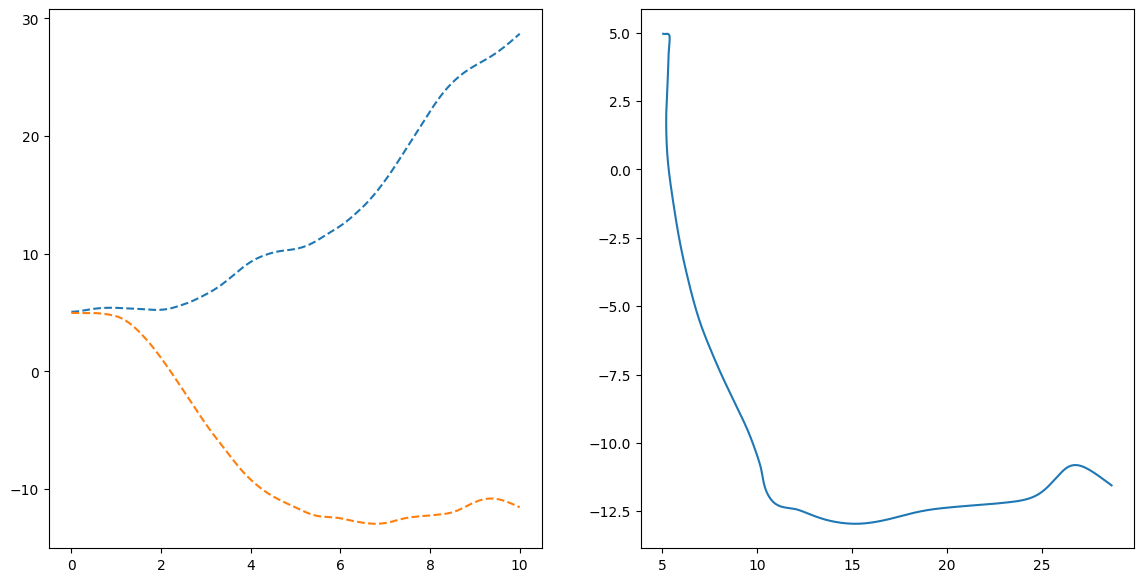

In [14]:
xs3 = jnp.array(x_seq)[::-1]
us3 = jnp.array(u_seq)
tt1 = jnp.arange(0, (blocks*steps)+1) * clqt.T  / steps/ blocks
f, (ax1, ax2) = plt.subplots(1,2, figsize=(14,7))
ax1.plot(tt1, xs3[:,0], '--', tt1, xs3[:,1], '--')


ax2.plot(xs3[:,0], xs3[:,1])


In [15]:
dt = clqt.T / steps / blocks

Kx_par, d_par, S_par, v_par = parBackwardPass(clqt,blocks,steps,t0,dt)
phi0= jnp.linalg.solve(S_par[0] ,v_par[0])

u_par,x_par = parForwardPass(clqt, phi0, Kx_par, d_par, blocks, steps,dt,t0,u_zoh=False)

In [16]:
phis1 = jnp.linalg.solve(S_par, v_par[..., None]).squeeze(-1)

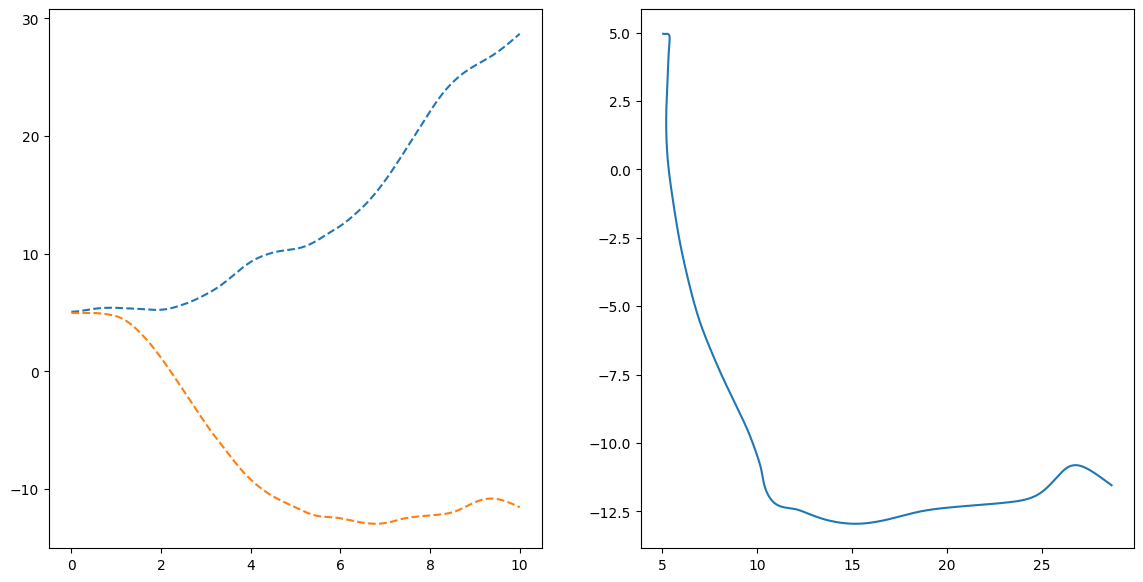

In [17]:
xs4 = jnp.array(x_par)[::-1]

us4 = jnp.array(u_par)
tt1 = jnp.arange(0, (blocks*steps)+1) * clqt.T  / steps/blocks


ff, (ax1, ax2) = plt.subplots(1,2, figsize=(14,7))
ax1.plot(tt1, xs4[:,0], '--', tt1, xs4[:,1], '--')
ax2.plot(xs4[:,0], xs4[:,1])


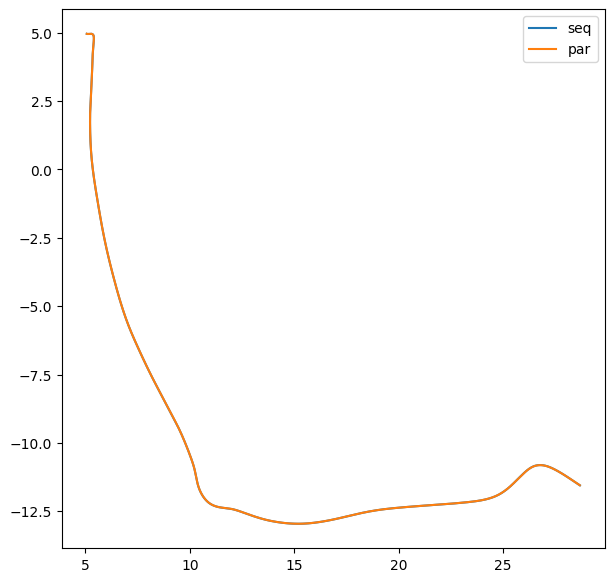

In [18]:
f, (ax1) = plt.subplots(1, figsize=(7,7))

ax1.plot(xs3[:,0], xs3[:,1])
ax1.plot( xs4[:,0],xs4[:,1])
ax1.legend( ['seq', 'par'])


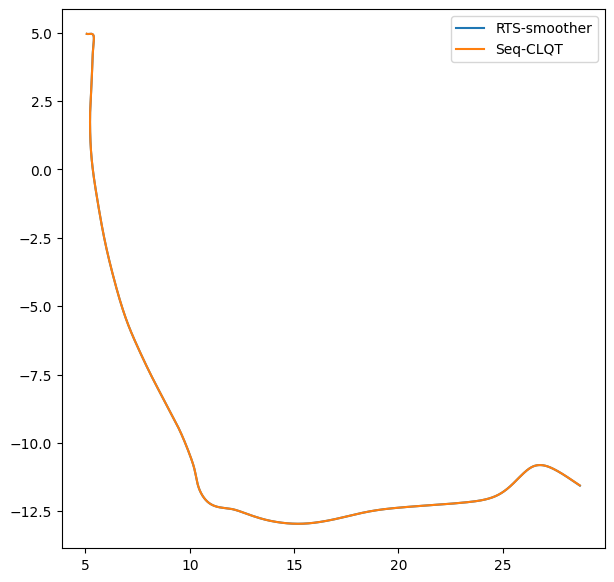

In [19]:
f, (ax1) = plt.subplots(1,1, figsize=(7,7))

ax1.plot(ms_s[:,0], ms_s[:,1])
ax1.plot(xs3[:,0], xs3[:,1])
ax1.legend( ['RTS-smoother', 'Seq-CLQT'])


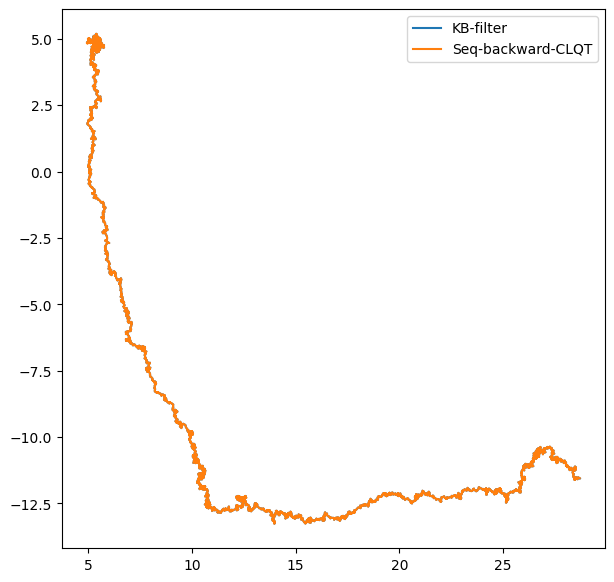

In [20]:
f, (ax1) = plt.subplots(1,1, figsize=(7,7))

ax1.plot(ms[:,0], ms[:,1])
ax1.plot(phis[:,0], phis[:,1])
ax1.legend( ['KB-filter', 'Seq-backward-CLQT'])


In [21]:
Kx_par, d_par, S_par, v_par = parBackwardPass(clqt, blocks, steps, t0, dt)
phi0= jnp.linalg.solve(S_par[0] ,v_par[0])
u_par_fb,x_par_fb = parFwdBwdPass(clqt, phi0,Kx_par, d_par, S_par, v_par, blocks, steps, dt, t0)

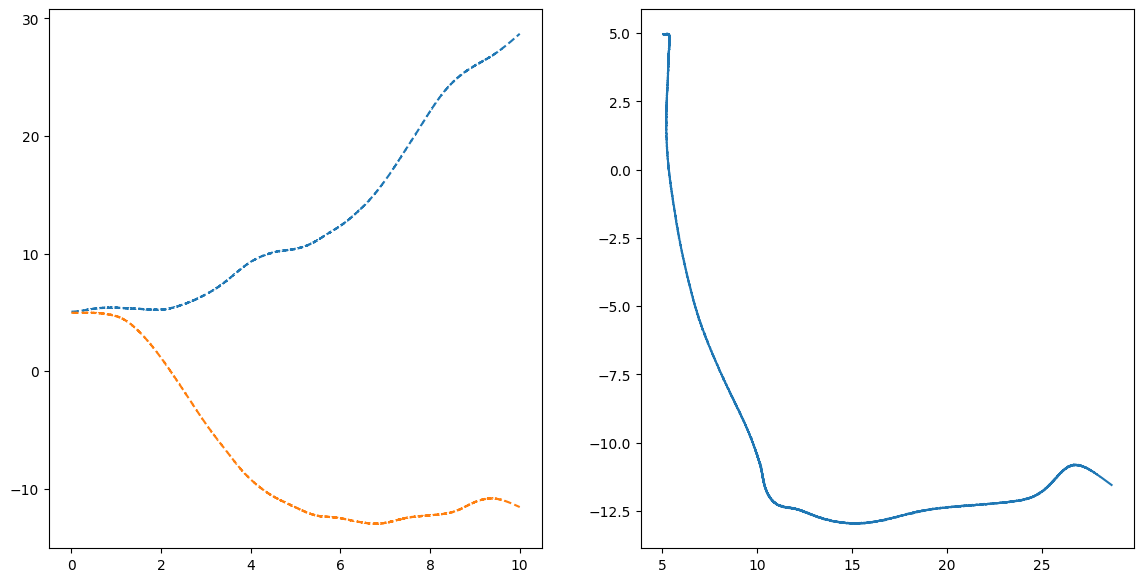

In [22]:
xs5 = jnp.array(x_par_fb)[::-1]

us5 = jnp.array(u_par_fb)
tt1 = jnp.arange(0, (blocks*steps)+1) * clqt.T  / steps/blocks


ff, (ax1, ax2) = plt.subplots(1,2, figsize=(14,7))
ax1.plot(tt1, xs5[:,0], '--', tt1, xs5[:,1], '--')
ax2.plot(xs5[:,0], xs5[:,1])


In [23]:
from cmap.clqt_jax import seqFwdBwdPass
from cmap.clqt_jax import combine_seqFwdBwdPass

In [24]:
S_seq, v_seq, Kx_seq, d_seq = seqBackwardPass(clqt,steps*blocks,dt,t0,ST,vT)
phi0= jnp.linalg.solve(S_seq[0] ,v_seq[0])
A_all,b_all,C_all = seqFwdBwdPass(clqt,steps_all,dt,t0,jnp.eye(4),phi0,jnp.zeros((4,4)))

In [25]:
us6,xs6 = combine_seqFwdBwdPass(S_seq,Kx_seq,v_seq,d_seq,A_all,b_all,C_all)

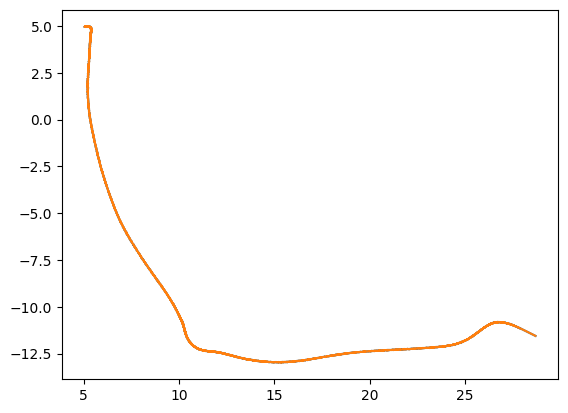

In [26]:
plt.plot(xs6[:,0], xs6[:,1])
plt.plot(xs5[:,0], xs5[:,1])